In [1]:
### makes the single lat overview fig for QACC paper/chapter

## fig is AOD, temp evolution and Arctic spatial pattern of T change. 

# v3 is update post viva, to add a few edits to the main fig

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import logging
#import esmvalcore.preprocessor
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
from scipy import stats
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams.update({'font.size': 15})
import dask
from Utils import weighted_annual_resample, get_ds_from_ceda, spatial_mean

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91]}

regions = ['Global', 'Arctic', 'Tropics']

min_year_late_cent, max_year_late_cent = '2050', '2069'

### set up read-in for MH's 1.5C runs:

MH_run_archive = '/gws/ssde/j25b/moghli/MH_runs/'


MH_EQ_runs = ['u-de029', 'u-de034', 'u-cy805']
MH_15_runs = ['u-cu743', 'u-cy806', 'u-cy807']
MH_30_runs = ['u-cr991', 'u-cs992', 'u-cs993', 'u-cs994', 'u-cs995']
MH_60_runs = ['u-ct762', 'u-cy808', 'u-cy809']

MH_inj_loc_dict = {'EQ':MH_EQ_runs,
                   '15':MH_15_runs,
                   '30':MH_30_runs,
                   '60':MH_60_runs,
                   }

SAI_runs = {'u-de029':'EQ',
            'u-de034':'EQ',
            'u-cy805':'EQ',
            'u-cu743':'15',
            'u-cy806':'15',
            'u-cy807':'15',
            'u-cr991':'30',
            'u-cs992':'30',
            'u-cs993':'30',
            'u-cs994':'30',
            'u-cs995':'30',
            'u-ct762':'60',
            'u-cy808':'60',
            'u-cy809':'60'
           }

extra_aod_data_for_EQ_path = MH_run_archive+'extra_strataod'

In [3]:
### first get AOD: 
def get_alt_source_aod(run):
    ds_list = []
    files = os.listdir(extra_aod_data_for_EQ_path)
    for f in files:
        if run in f:
            ds = xr.open_dataset(os.path.join(extra_aod_data_for_EQ_path, f))
            ds_list.append(ds)
    combined = xr.merge(ds_list)
    out_da = combined['m01s02i251'] + combined['m01s02i252'] + combined['m01s02i253'] + combined['m01s02i254']
    out_ds = out_da.to_dataset(name='strataod')
    return out_ds

def get_ds(run):
    if run in MH_EQ_runs:
        ds = get_alt_source_aod(run).mean('longitude')
    else:
        ds =  xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/{r}/ukesm_{r}_small.nc'.format(r=run))[['strataod']]
        ds = ds.dropna(dim="latitude", how="all")
    return ds

ds_list, runs = [], []
for run in SAI_runs.keys():
    print(run)
    runs.append(run)
    ds_list.append(get_ds(run).sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time'))

ds_dict_sai = dict(zip(runs, ds_list))

ds_EQ = xr.concat([ds_dict_sai[r] for r in MH_EQ_runs], dim='Ensemble_member')
ds_15 = xr.concat([ds_dict_sai[r] for r in MH_15_runs], dim='Ensemble_member')
ds_30 = xr.concat([ds_dict_sai[r] for r in MH_30_runs], dim='Ensemble_member')
ds_60 = xr.concat([ds_dict_sai[r] for r in MH_60_runs], dim='Ensemble_member')

ds_dict_sai_grouped = dict(zip(['EQ', '15', '30', '60'], [ds_EQ, ds_15, ds_30, ds_60]))

u-de029
u-de034
u-cy805
u-cu743
u-cy806
u-cy807
u-cr991
u-cs992
u-cs993
u-cs994
u-cs995
u-ct762
u-cy808
u-cy809


In [4]:
## also get the ARISE-1.5K AOD: 

paths_arise_sAOD = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Emon/od550aerso/gn/*/')
ds_list_arise = []
for p in paths_arise_sAOD:
    run_id = p.split('/')[-6]
    print(run_id)
    ds = xr.open_mfdataset(p+'/*.nc', combine='by_coords')
    ds = ds.sel(time=slice('2050', '2069'))
    ds_list_arise.append(ds.mean('time').mean('lon').rename({'lat':'latitude'}))
ds_arise_sAOD = xr.concat(ds_list_arise, dim='Ensemble_member')
ds_arise_sAOD

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2


<xarray.Dataset> Size: 16kB
Dimensions:     (latitude: 144, Ensemble_member: 5, bnds: 2)
Coordinates:
  * latitude    (latitude) float64 1kB -89.38 -88.12 -86.88 ... 88.12 89.38
    wavelength  float64 8B 550.0
Dimensions without coordinates: Ensemble_member, bnds
Data variables:
    lat_bnds    (Ensemble_member, latitude, bnds) float64 12kB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    lon_bnds    (Ensemble_member, bnds) float64 80B dask.array<chunksize=(1, 2), meta=np.ndarray>
    od550aerso  (Ensemble_member, latitude) float32 3kB dask.array<chunksize=(1, 144), meta=np.ndarray>

In [5]:
matplotlib.rcParams.update({'font.size': 15})

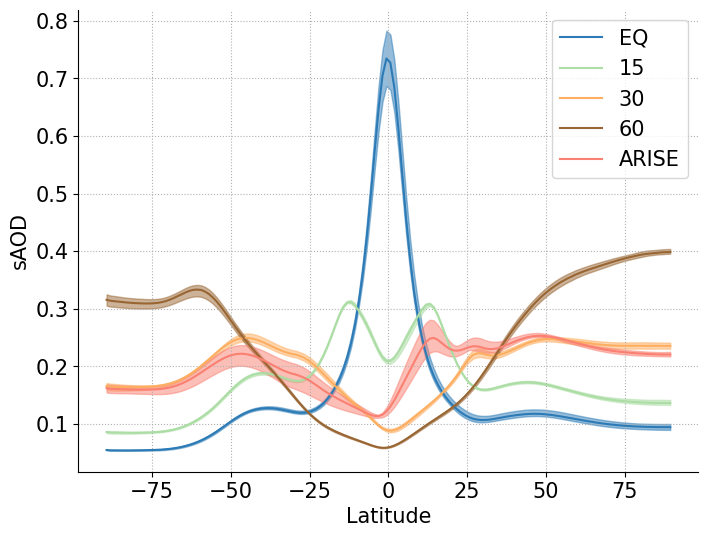

In [6]:
## plot AOD:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
t_col = 'black'
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633'}


#ax.plot(ds_EQ.latitude.values, ds_EQ.strataod, c=colours['EQ'], label='EQ')

for run in ds_dict_sai_grouped:
    data = ds_dict_sai_grouped[run]
    ax.plot(data.mean('Ensemble_member').latitude.values, data.mean('Ensemble_member').strataod, c=colours[run], label=run)
    ax.fill_between(data.isel(Ensemble_member=0).latitude.values, 
                    data.min('Ensemble_member').strataod.values, 
                    data.max('Ensemble_member').strataod.values, 
                    color=colours[run], alpha=0.5)


# also plot ARISE:
data = ds_arise_sAOD
ax.plot(data.mean('Ensemble_member').latitude.values, data.mean('Ensemble_member').od550aerso, c='salmon', label='ARISE')
ax.fill_between(data.isel(Ensemble_member=0).latitude.values, 
                data.min('Ensemble_member').od550aerso.values, 
                data.max('Ensemble_member').od550aerso.values, 
                color='salmon', alpha=0.5)

ax.legend()
ax.grid(ls='dotted')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('sAOD')
ax.set_xlabel('Latitude')
plt.savefig('figures/AOD.jpg', dpi=350, bbox_inches='tight')

In [7]:
## now get temp evolutions: 

def get_MH_run_tas(run):
    ds =  xr.open_dataset('/gws/ssde/j25b/moghli/MH_runs/{r}/ukesm_{r}_small.nc'.format(r=run))[['air_temperature']]
    
    ds = ds.rename({'air_temperature':'tas'})
    ds = ds.rename({'latitude':'y', 'longitude':'x'})
    #ds = ds.mean('x')
    ds.load()

    # take the global mean
    ds_global = ds.mean('x')
    weights = np.cos(np.deg2rad(ds_global.y))
    weights.name = "weights"
    ds_global_weighted = ds_global.weighted(weights)
    ds_global_smean = ds_global_weighted.mean("y")
    ds_global_smeantmean = ds_global_smean.sel(time=slice(min_year_late_cent, max_year_late_cent)).groupby("time.month").mean(dim="time")

    # and take the arctic time mean:
    ds_arctic = ds.mean('x').sel(y=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1]))
    weights = np.cos(np.deg2rad(ds_arctic.y))
    weights.name = "weights"
    ds_arctic_weighted = ds_arctic.weighted(weights)
    ds_arctic_smean = ds_arctic_weighted.mean("y")
    ds_arctic_smeantmean = ds_arctic_smean.sel(time=slice(min_year_late_cent, max_year_late_cent)).groupby("time.month").mean(dim="time")
    
    return {'data':ds, 
            'Global_spatial_mean_yearly':weighted_annual_resample(ds_global_smean, 'tas'), 
            'Global_monthly_spatialtime_mean':ds_global_smeantmean,
            'Arctic_spatial_mean_yearly':weighted_annual_resample(ds_arctic_smean, 'tas'),
            'Arctic_monthly_spatialtime_mean':ds_arctic_smeantmean}

In [8]:
datas, runs = [], []
for run in SAI_runs:
    runs.append(run)
    data = get_MH_run_tas(run)
    datas.append(data)
all_tas_dict_sai = dict(zip(runs, datas))

In [9]:

tas_gsm_dict_sai = dict(zip(SAI_runs, [all_tas_dict_sai[r]['Global_spatial_mean_yearly'] for r in SAI_runs]))
tas_asm_dict_sai = dict(zip(SAI_runs, [all_tas_dict_sai[r]['Arctic_spatial_mean_yearly'] for r in SAI_runs]))

gsm_dict_sai_grouped = dict(zip(['EQ', '15', '30', '60'], [xr.concat([tas_gsm_dict_sai[r] for r in MH_group], dim='Ensemble_member') for MH_group in [MH_EQ_runs, MH_15_runs, MH_30_runs, MH_60_runs]]))
asm_dict_sai_grouped = dict(zip(['EQ', '15', '30', '60'], [xr.concat([tas_asm_dict_sai[r] for r in MH_group], dim='Ensemble_member') for MH_group in [MH_EQ_runs, MH_15_runs, MH_30_runs, MH_60_runs]]))

In [10]:
ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']
DS_ssp245_tas = weighted_annual_resample(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069'))

DS_ssp245_tas.load()

SSP245_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_tas, region, lat_band_dict=lat_band_dict) for region in regions]))

In [11]:
# also read in the ARISE temp data:
paths_tas_ARISE = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')
ds_list_arise_tas = []
for p in paths_tas_ARISE:
    run_id = p.split('/')[-6]
    print(run_id)
    ds = xr.open_mfdataset(p+'/*.nc', combine='by_coords')
    ds = ds.rename({'lat':'y', 'lon':'x'})
    ds_list_arise_tas.append(ds)
ds_arise_tas = weighted_annual_resample(xr.concat(ds_list_arise_tas, dim='Ensemble_member'), 'tas')
ds_arise_tas.load()

arise_tas_timeseries_dict = dict(zip(regions, [spatial_mean(ds_arise_tas, region, lat_band_dict=lat_band_dict) for region in regions]))

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2


In [12]:
arctic_target = SSP245_timeseries_dict['Arctic'].sel(time=slice('2015', '2032')).mean().tas.item()

In [13]:
piCo_arctic = 257.9831104902884 # annual mean PiControl temp in arctic region in UKESM1
piCo_global = 288.06-1.5 # annual global mean PiControl temp in UKESM1

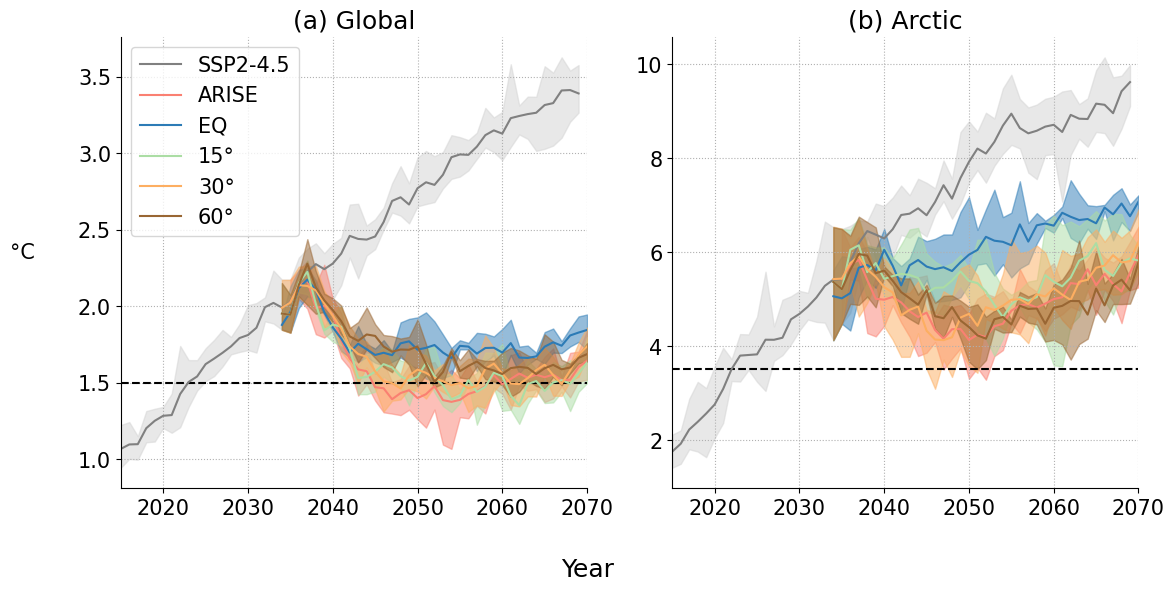

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
t_col = 'black'
#alt_linestyles = {'13km':'solid', '15km':'-.'}

colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633'}

targets = [1.5, arctic_target-piCo_arctic]
i=0
for region in ['Global', 'Arctic']:
    ax = axs[i]
    ax.axhline(targets[i], color='black', ls='--')
    ts_ssp245 = SSP245_timeseries_dict[region].tas
    piCo = [piCo_global, piCo_arctic][i]
    ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo), c=colours['ssp245'], label='SSP2-4.5')
    ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                    ts_ssp245.min('Ensemble_member').values - piCo, 
                    ts_ssp245.max('Ensemble_member').values - piCo, 
                    color=colours['ssp245_light'], alpha=0.5)

    # do same for ARISE: 
    ts_arise = arise_tas_timeseries_dict[region].tas
    ax.plot(ts_arise.mean('Ensemble_member').time.dt.year.values, (ts_arise.mean('Ensemble_member') - piCo), c='salmon', label='ARISE')
    ax.fill_between(ts_arise.isel(Ensemble_member=0).time.dt.year.values,
                    ts_arise.min('Ensemble_member').values - piCo, 
                    ts_arise.max('Ensemble_member').values - piCo, 
                    color='salmon', alpha=0.5)
    #ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
    
    for lat in ['EQ', '15', '30', '60']:
        data = gsm_dict_sai_grouped[lat] if region == 'Global' else asm_dict_sai_grouped[lat]
        #ax.plot(data.time.dt.year,(data.tas - piCo), c=colours[SAI_runs[run]])
        ax.plot(data.mean('Ensemble_member').time.dt.year.values, (data.mean('Ensemble_member').tas - piCo), color=colours[lat])
        ax.fill_between(data.isel(Ensemble_member=0).time.dt.year.values, 
                        data.tas.min('Ensemble_member').values - piCo, 
                        data.tas.max('Ensemble_member').values - piCo, 
                        color=colours[lat], alpha=0.5)

    j=0
    
    for inj in ['EQ', '15', '30', '60']:
        label=inj
        if j >0:
            label = inj + '°' 
        ax.plot([], [], color=colours[inj], label=label)
        j=j+1

    ax.grid(ls='dotted')
    if region == 'Global':
         ax.legend(ncols=1)
    i=i+1


for ax in axs.flatten():
    ax.set_xlim(2015, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0].set_title('(a) Global')
axs[1].set_title('(b) Arctic')


axs[0].set_ylabel('°C', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('figures/temp_timeseries_lats_and_ARISE.jpg', dpi=350)

In [15]:
# now make the spatial patterns of T change in the Arctic:

### plot some maps: 

map_ssp245 = DS_ssp245_tas.sel(time=slice('2050', '2070')).mean(['time', 'Ensemble_member'])
map_base = DS_ssp245_tas.sel(time=slice('2014', '2032')).mean(['time', 'Ensemble_member'])

spatial_tas_dict_sai_grouped = dict(zip(['EQ', '15', '30', '60'], [xr.concat([all_tas_dict_sai[r]['data'] for r in MH_group], dim='Ensemble_member') for MH_group in [MH_EQ_runs, MH_15_runs, MH_30_runs, MH_60_runs]]))

ds_EQ = spatial_tas_dict_sai_grouped['EQ']
ds_60 = spatial_tas_dict_sai_grouped['60']

map_EQ = ds_EQ.sel(time=slice('2050', '2070')).mean(['time', 'Ensemble_member']).dropna(dim="y", how="all").dropna(dim="x", how="all")
map_60 = ds_60.sel(time=slice('2050', '2070')).mean(['time', 'Ensemble_member']).dropna(dim="y", how="all").dropna(dim="x", how="all")
map_arise = ds_arise_tas.sel(time=slice('2050', '2070')).mean(['time', 'Ensemble_member'])

percEQ = -100*((map_EQ.tas - map_ssp245.tas)/(map_ssp245.tas-map_base.tas))
perc60 = -100*((map_60.tas - map_ssp245.tas)/(map_ssp245.tas-map_base.tas))
percarise = -100*((map_arise.tas - map_ssp245.tas)/(map_ssp245.tas-map_base.tas))

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point # Import add_cyclic_point

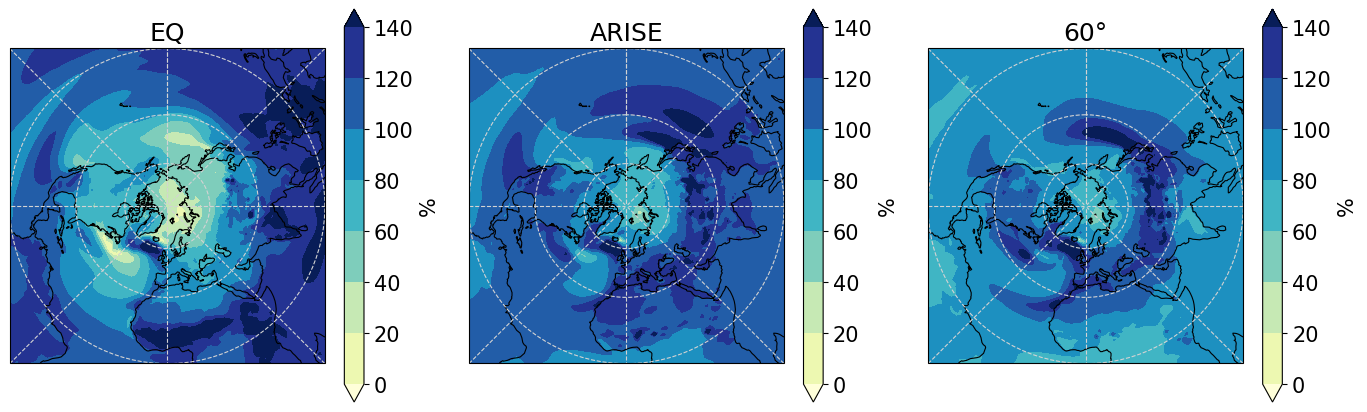

In [17]:

percEQ_nh = percEQ.sel(y=(percEQ['y'] > -20))
perc60_nh = perc60.sel(y=(perc60['y'] > -20))
percarise_nh = percarise.sel(y=(percarise['y'] > -20))

cyclic_data_eq, cyclic_lons_eq = add_cyclic_point(percEQ_nh.values, coord=percEQ_nh['x'])
percEQ_nh_cyclic = xr.DataArray(
    cyclic_data_eq,
    coords={'y': percEQ_nh['y'], 'x': cyclic_lons_eq},
    dims=['y', 'x'],
    name=percEQ_nh.name,
    attrs=percEQ_nh.attrs
)

cyclic_data_60, cyclic_lons_60 = add_cyclic_point(perc60_nh.values, coord=perc60_nh['x'])
perc60_nh_cyclic = xr.DataArray(
    cyclic_data_60,
    coords={'y': perc60_nh['y'], 'x': cyclic_lons_60},
    dims=['y', 'x'],
    name=perc60_nh.name,
    attrs=perc60_nh.attrs
)

# repeat for arise
cyclic_data_arise, cyclic_lons_arise = add_cyclic_point(percarise_nh.values, coord=percarise_nh['x'])
percarise_nh_cyclic = xr.DataArray(
    cyclic_data_arise,
    coords={'y': percarise_nh['y'], 'x': cyclic_lons_arise},
    dims=['y', 'x'],
    name=percarise_nh.name,
    attrs=percarise_nh.attrs
)


fig, axes = plt.subplots(1, 3, figsize=(14, 7), subplot_kw={'projection': ccrs.NorthPolarStereo()})

extent = [-180, 180, 0, 90]

contour_levels = np.arange(0, 141, 20)


ax0 = axes[0]
cyclic_data_eq, cyclic_lons_eq = add_cyclic_point(percEQ_nh.values, coord=percEQ_nh['x'])
percEQ_nh_cyclic.plot.contourf(
    ax=ax0,
    x='x', y='y', 
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu', 
    cbar_kwargs={'label': '%','shrink':0.6}, 
    add_colorbar=True,
    extend='both', 
    levels=contour_levels)

ax0.set_title('EQ')
ax0.set_extent(extent, crs=ccrs.PlateCarree())

ax1 = axes[1]
percarise_nh_cyclic.plot.contourf(
    ax=ax1,
    x='x', y='y',
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu', 
    cbar_kwargs={'label': '%', 'shrink':0.6}, 
    add_colorbar=True,
    extend='both',
    levels=contour_levels)
ax1.set_title('ARISE')
ax1.set_extent(extent, crs=ccrs.PlateCarree())

ax2 = axes[2] 
perc60_nh_cyclic.plot.contourf(
    ax=ax2,
    x='x', y='y',
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu', 
    cbar_kwargs={'label': '%', 'shrink':0.6}, 
    add_colorbar=True,
    extend='both',
    levels=contour_levels)

ax2.set_title('60°') 
ax2.set_extent(extent, crs=ccrs.PlateCarree())


for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')


plt.tight_layout()
plt.savefig('figures/EQ_arise_60_frac_cooling_plots.jpg', dpi=350)
plt.show()

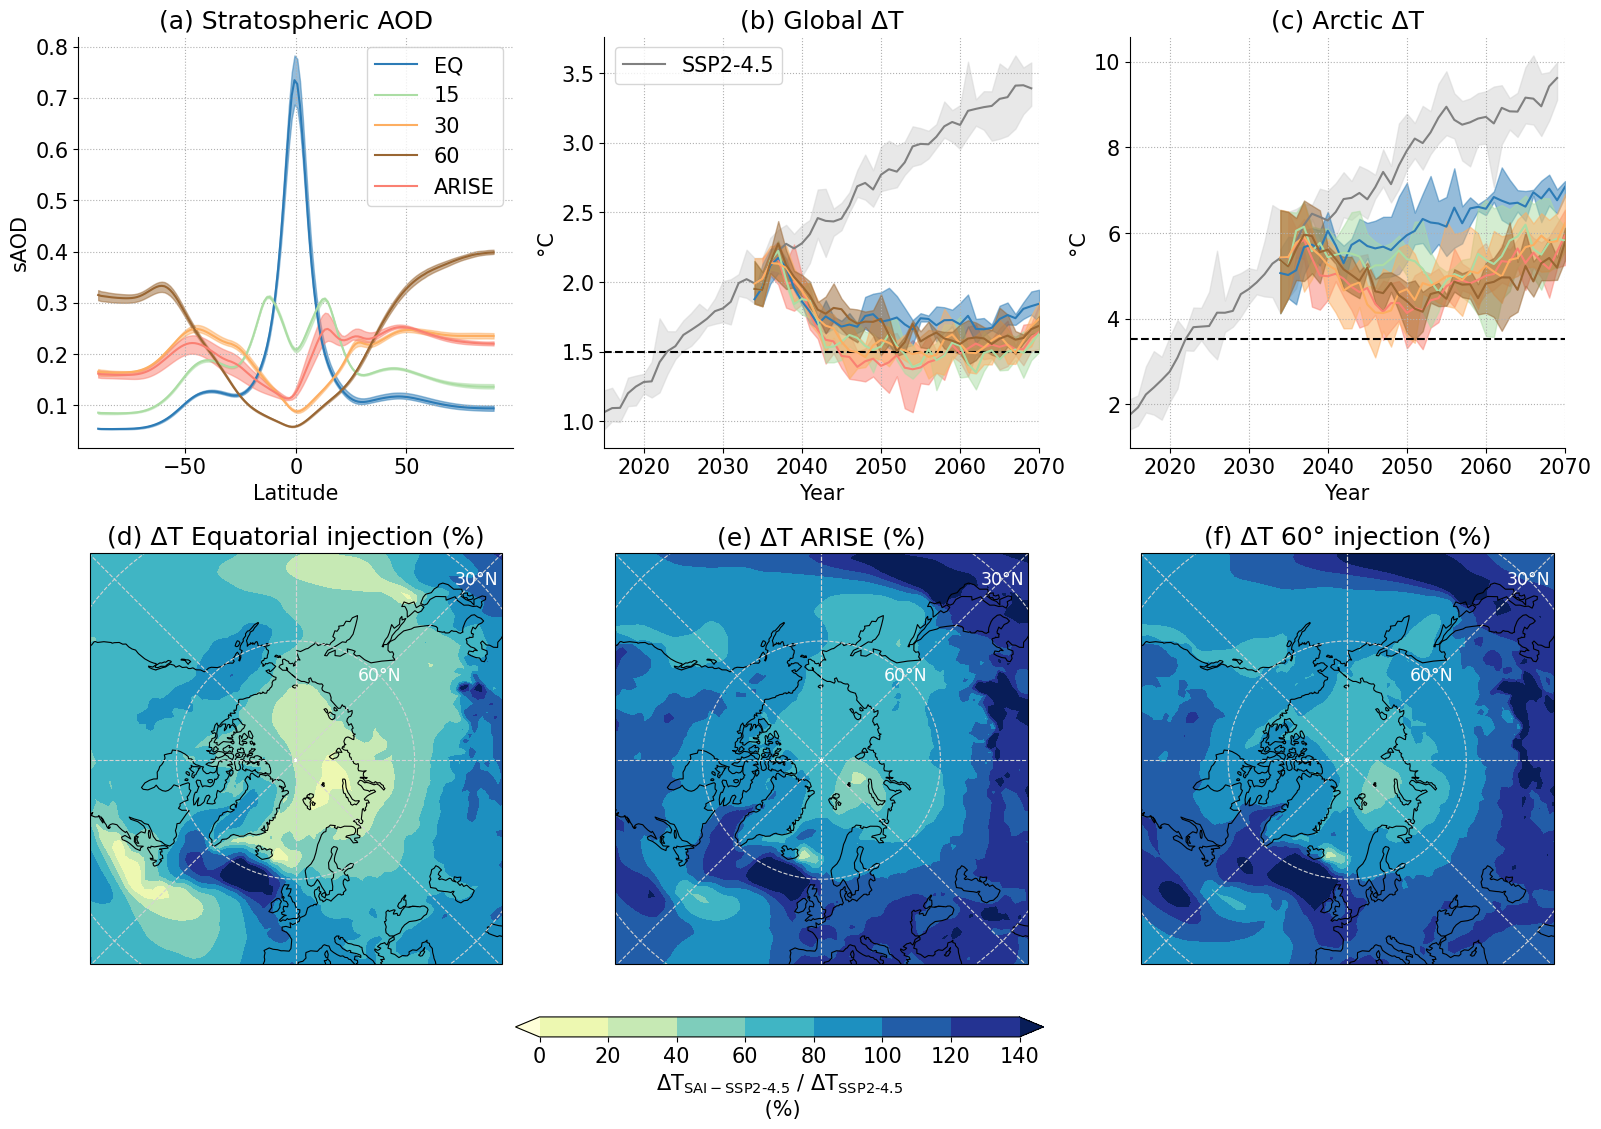

In [18]:
## now make one large figure that combines all the above figures, with AOD, then temperature timeseries, then spatial plots as the bottom row. 

fig = plt.figure(constrained_layout=True, figsize=(16, 10))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
# AOD plot
t_col = 'black'
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'EQ':'#2C7BB6',
           '15':'#ABDDA4',
           '30':'#FDAE61',
           '60':'#996633'}
for run in ds_dict_sai_grouped:
    data = ds_dict_sai_grouped[run]
    ax1.plot(data.mean('Ensemble_member').latitude.values, data.mean('Ensemble_member').strataod, c=colours[run], label=run)
    ax1.fill_between(data.isel(Ensemble_member=0).latitude.values, 
                    data.min('Ensemble_member').strataod.values, 
                    data.max('Ensemble_member').strataod.values, 
                    color=colours[run], alpha=0.5)
# also plot ARISE:
data = ds_arise_sAOD
ax1.plot(data.mean('Ensemble_member').latitude.values, data.mean('Ensemble_member').od550aerso, c='salmon', label='ARISE')
ax1.fill_between(data.isel(Ensemble_member=0).latitude.values, 
                data.min('Ensemble_member').od550aerso.values, 
                data.max('Ensemble_member').od550aerso.values, 
                color='salmon', alpha=0.5)
ax1.legend()
ax1.grid(ls='dotted')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('sAOD')
ax1.set_xlabel('Latitude')
ax1.set_title('(a) Stratospheric AOD')

# temperature timeseries plots
ax2, ax3 = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])
targets = [1.5, arctic_target-piCo_arctic]
i=0
for region in ['Global', 'Arctic']:
    ax = ax2 if i==0 else ax3
    ax.axhline(targets[i], color='black', ls='--')
    ts_ssp245 = SSP245_timeseries_dict[region].tas
    piCo = [piCo_global, piCo_arctic][i]
    ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo), c=colours['ssp245'], label='SSP2-4.5' if i==0 else None)
    ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                    ts_ssp245.min('Ensemble_member').values - piCo, 
                    ts_ssp245.max('Ensemble_member').values - piCo, 
                    color=colours['ssp245_light'], alpha=0.5)
    # do same for ARISE: 
    ts_arise = arise_tas_timeseries_dict[region].tas
    ax.plot(ts_arise.mean('Ensemble_member').time.dt.year.values, (ts_arise.mean('Ensemble_member') - piCo), c='salmon')
    ax.fill_between(ts_arise.isel(Ensemble_member=0).time.dt.year.values,
                    ts_arise.min('Ensemble_member').values - piCo, 
                    ts_arise.max('Ensemble_member').values - piCo, 
                    color='salmon', alpha=0.5)
    for lat in ['EQ', '15', '30', '60']:
        data = gsm_dict_sai_grouped[lat] if region == 'Global' else asm_dict_sai_grouped[lat]
        ax.plot(data.mean('Ensemble_member').time.dt.year.values, (data.mean('Ensemble_member').tas - piCo), color=colours[lat])
        ax.fill_between(data.isel(Ensemble_member=0).time.dt.year.values, 
                        data.tas.min('Ensemble_member').values - piCo, 
                        data.tas.max('Ensemble_member').values - piCo, 
                        color=colours[lat], alpha=0.5)
    i=i+1
for ax in ax2, ax3:    
    ax.set_xlim(2015, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('°C')
    ax.set_xlabel('Year')
    ax.grid(ls='dotted')

ax2.legend(loc='upper left')
ax2.set_title('(b) Global ΔT')
ax3.set_title('(c) Arctic ΔT')

# spatial plots
ax4, ax5, ax6 = fig.add_subplot(gs[1, 0], projection=ccrs.NorthPolarStereo()), fig.add_subplot(gs[1, 1], projection=ccrs.NorthPolarStereo()), fig.add_subplot(gs[1, 2], projection=ccrs.NorthPolarStereo())
extent = [-180, 180, 40, 90]
contour_levels = np.arange(0, 141, 20)

cs = percEQ_nh_cyclic.plot.contourf(
        ax=ax4,
        x='x', y='y', 
        transform=ccrs.PlateCarree(),
        cmap='YlGnBu', 
        #cbar_kwargs={'label': '%','shrink':0.6}, 
        add_colorbar=False,
        extend='both', 
        levels=contour_levels)

cs = percarise_nh_cyclic.plot.contourf(
        ax=ax5,
        x='x', y='y',
        transform=ccrs.PlateCarree(),
        cmap='YlGnBu', 
        #cbar_kwargs={'label': '%', 'shrink':0.6}, 
        add_colorbar=False,
        extend='both',
        levels=contour_levels)

cs = perc60_nh_cyclic.plot.contourf(
        ax=ax6,
        x='x', y='y',
        transform=ccrs.PlateCarree(),
        cmap='YlGnBu', 
        #cbar_kwargs={'label': '%', 'shrink':0.6}, 
        add_colorbar=False,
        extend='both',
        levels=contour_levels)

ax4.set_title('(d) ΔT Equatorial injection (%)')
ax5.set_title('(e) ΔT ARISE (%)')
ax6.set_title('(f) ΔT 60° injection (%)')
for ax in ax4, ax5, ax6:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    gl = ax.gridlines(draw_labels=True, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False  # set True if you also want longitude labels
    gl.left_labels = True     # latitude labels on the left side
    gl.ylabel_style = {'color': 'white', 'fontsize': 'small'}
    
    
plt.tight_layout()

# add colorbar horizontal at bottom
cbar_ax = fig.add_axes([0.33, -0.05, 0.33, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
#cbar.set_label('ΔT$_{SAI - SSP2-4.5}}$ / ΔT$_{SSP2-4.5}$ /%')
cbar.set_label(r'$\Delta$T$_{\mathrm{SAI - SSP2\text{-}4.5}}$ / $\Delta$T$_{\mathrm{SSP2\text{-}4.5}}$' + '\n (%)')

#plt.tight_layout()
plt.savefig('figures/Combined_overview_figure.jpg', dpi=350, bbox_inches='tight')
plt.show()

In [19]:
### now add a scatter plot for arctic cooling per unit global cooling

def cooling_ratio(arctic_ts, global_ts):
    mems = len(arctic_ts.Ensemble_member)
    arctic_cooling = arctic_ts.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time') - SSP245_timeseries_dict['Arctic'].isel(Ensemble_member=slice(0, mems)).tas.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean(['time', 'Ensemble_member'])
    global_cooling = global_ts.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time') - SSP245_timeseries_dict['Global'].isel(Ensemble_member=slice(0, mems)).tas.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean(['time', 'Ensemble_member'])
    return arctic_cooling/global_cooling


In [20]:
## get the UKESM AA ratio to add to the plot:
warming_global = SSP245_timeseries_dict['Global'].sel(time=slice('2050', '2069')).mean(['Ensemble_member', 'time']).tas.item() - SSP245_timeseries_dict['Global'].sel(time=slice('2015', '2035')).mean(['Ensemble_member', 'time']).tas.item()
warming_arctic = SSP245_timeseries_dict['Arctic'].sel(time=slice('2050', '2069')).mean(['Ensemble_member', 'time']).tas.item() - SSP245_timeseries_dict['Arctic'].sel(time=slice('2015', '2035')).mean(['Ensemble_member', 'time']).tas.item()
AA = warming_arctic/warming_global
print(AA)

3.1898646192782856


In [21]:

def get_inj_mag_MH(run):
    log = pd.read_csv(MH_run_archive + '{r}/FeedBack_stats_{rs}_2034.log'.format(r=run, rs=run.split('-')[1]))
    cols = ['30S(Tg)', '15S(Tg)', '15N(Tg)', '30N(Tg)']
    mean_inj = np.sum([np.mean(log[log['Timestamp']>2049][col]) for col in cols])
    if run in MH_EQ_runs:
        return mean_inj/2
    else:
        return mean_inj

get_inj_mag_MH('u-cr991')

# plus get the arise injection magnitudes:
injs_UK = []
names = []
UKESM_ARISE_run_IDs = ['cl322', 'cl458', 'cl459', 'cl460', 'cl461']
UKESM_ARISE_run_dict = {'cl322':'r1i1p1f2', 'cl458':'r2i1p1f2', 'cl459':'r3i1p1f2',
                        'cl460':'r4i1p1f2', 'cl461':'r8i1p1f2'}
UKESM_arise_inj_logs_path = '~/UKESM_runs_analysis/HiLLA-SAI/Extra_data/ARISE_injection_stats/UKESM_feedback_stats/'
for run in UKESM_ARISE_run_IDs: 
    file = UKESM_arise_inj_logs_path+'FeedBack_stats_{}_2034.log'.format(run)
    log = pd.read_csv(file)
    log = log[log['Timestamp'] < 2069+1]
    log = log[log['Timestamp'] > 2050-1]
    injs_UK.append(np.mean(log[['30S(Tg)', '15S(Tg)', '15N(Tg)', '30N(Tg)']].sum(axis=1)))
    names.append(UKESM_ARISE_run_dict[run])
    
arise_injs = dict(zip(names, injs_UK))

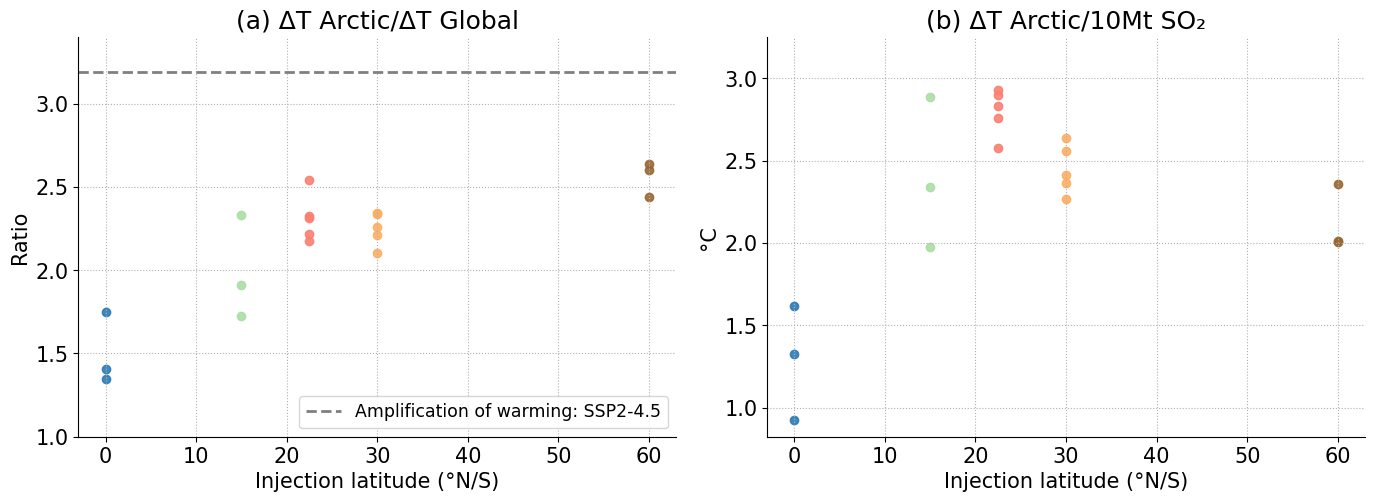

In [22]:
### now combine these two scatter plots into one figure:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for lat in ['EQ', '15', '30', '60']:
    ratios = cooling_ratio(asm_dict_sai_grouped[lat], gsm_dict_sai_grouped[lat])
    x = int(lat) if lat != 'EQ' else 0
    for i in range(len(ratios.Ensemble_member)):
        ax1.scatter(x, ratios.isel(Ensemble_member=i).tas, c=colours[lat], marker='o', alpha=0.9, )
# also plot ARISE:
ratios = cooling_ratio(arise_tas_timeseries_dict['Arctic'], arise_tas_timeseries_dict['Global'])
for l in range(len(ratios.Ensemble_member)):
    ax1.scatter(22.5, ratios.isel(Ensemble_member=l).tas, c='salmon', marker='o', alpha=0.9)#, label='ARISE-1.5K' if l==0 else None)
## AA
ax1.axhline(AA, ls='--', c='gray', label='Amplification of warming: SSP2-4.5', lw=2)
ax1.set_ylim(1,)
ax1.set_xlabel('Injection latitude (°N/S)')
ax1.set_ylabel('Ratio')
ax1.legend(fontsize='small', loc='lower right')
ax1.grid(ls='dotted')
ax1.spines[['right', 'top']].set_visible(False)
ax1.set_ylim(None, 3.4)
# second plot
for lat in ['EQ', '15', '30', '60']:
    arctic_cooling = asm_dict_sai_grouped[lat].sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time') - SSP245_timeseries_dict['Arctic'].isel(Ensemble_member=slice(0, len(asm_dict_sai_grouped[lat].Ensemble_member))).tas.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
    for i in range(len(arctic_cooling.Ensemble_member)):
        inj = get_inj_mag_MH(MH_EQ_runs[i]) if lat == 'EQ' else get_inj_mag_MH(MH_15_runs[i]) if lat == '15' else get_inj_mag_MH(MH_30_runs[i]) if lat == '30' else get_inj_mag_MH(MH_60_runs[i])
        x = int(lat) if lat != 'EQ' else 0
        y = -10*arctic_cooling.isel(Ensemble_member=i).tas/inj
        ax2.scatter(x, y, c=colours[lat], marker='o', alpha=0.9)
# plus add arise:
arctic_cooling = arise_tas_timeseries_dict['Arctic'].sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time') - SSP245_timeseries_dict['Arctic'].isel(Ensemble_member=slice(0, len(arise_tas_timeseries_dict['Arctic'].Ensemble_member))).tas.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean(['time'])
for l in range(len(arctic_cooling.Ensemble_member)):
    inj = arise_injs[UKESM_ARISE_run_dict[UKESM_ARISE_run_IDs[l]]]
    x = 22.5
    y = -10*arctic_cooling.isel(Ensemble_member=l).tas/inj
    ax2.scatter(x, y, c='salmon', marker='o', alpha=0.9)#, label='ARISE-1.5K' if l==0 else None)
ax2.set_xlabel('Injection latitude (°N/S)')
ax2.set_ylabel('°C')
#ax.legend(fontsize='small', loc='lower right')
ax2.grid(ls='dotted')
ax2.spines[['right', 'top']].set_visible(False)
ax2.set_yticks(np.arange(1, 3.2, 0.5))
ax2.set_ylim(None ,3.25)
plt.tight_layout()

ax1.set_title('(a) ΔT Arctic/ΔT Global')
ax2.set_title('(b) ΔT Arctic/10Mt SO\u2082')

plt.savefig('figures/Combined_cooling_mags.jpg', dpi=300, bbox_inches='tight')

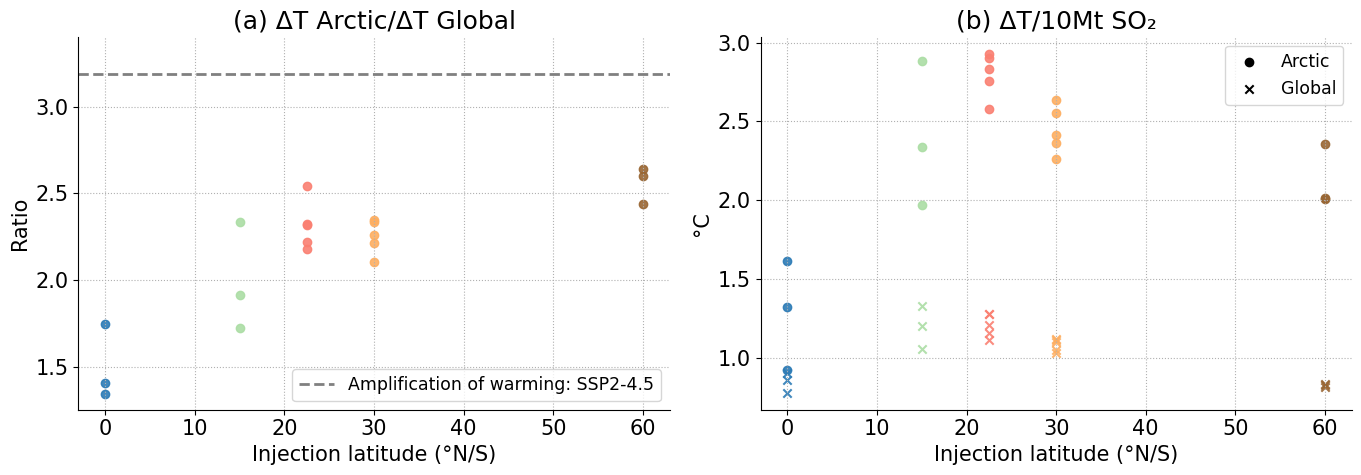

In [23]:
### Combined cooling mags, v2: right panel shows both Arctic and Global ΔT per unit injection

def late_cent_cooling(sai_ts, region):
    """Per-member late-century cooling of an SAI ensemble vs SSP2-4.5, for one region."""
    mems = len(sai_ts.Ensemble_member)
    return (sai_ts.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
            - SSP245_timeseries_dict[region].isel(Ensemble_member=slice(0, mems)).tas
                .sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

## --- (a) unchanged: ΔT Arctic / ΔT Global ratios ---
for lat in ['EQ', '15', '30', '60']:
    ratios = cooling_ratio(asm_dict_sai_grouped[lat], gsm_dict_sai_grouped[lat])
    x = int(lat) if lat != 'EQ' else 0
    for i in range(len(ratios.Ensemble_member)):
        ax1.scatter(x, ratios.isel(Ensemble_member=i).tas, c=colours[lat], marker='o', alpha=0.9)
ratios = cooling_ratio(arise_tas_timeseries_dict['Arctic'], arise_tas_timeseries_dict['Global'])
for l in range(len(ratios.Ensemble_member)):
    ax1.scatter(22.5, ratios.isel(Ensemble_member=l).tas, c='salmon', marker='o', alpha=0.9)
ax1.axhline(AA, ls='--', c='gray', label='Amplification of warming: SSP2-4.5', lw=2)
ax1.set_xlabel('Injection latitude (°N/S)')
ax1.set_ylabel('Ratio')
ax1.legend(fontsize='small', loc='lower right')
ax1.grid(ls='dotted')
ax1.spines[['right', 'top']].set_visible(False)
ax1.set_ylim(None, 3.4)

## --- (b) ΔT per 10 Mt SO2, Arctic (circles) and Global (triangles) ---
region_markers = {'Arctic': 'o', 'Global': 'x'}
region_xoffset = {'Arctic': 0, 'Global': 0}   # cosmetic, avoids overplotting

for lat in ['EQ', '15', '30', '60']:
    x0 = int(lat) if lat != 'EQ' else 0
    for region, sai_dict in [('Arctic', asm_dict_sai_grouped), ('Global', gsm_dict_sai_grouped)]:
        cooling = late_cent_cooling(sai_dict[lat], region)
        for i in range(len(cooling.Ensemble_member)):
            inj = get_inj_mag_MH(MH_inj_loc_dict[lat][i])
            y = -10 * cooling.isel(Ensemble_member=i).tas / inj
            ax2.scatter(x0 + region_xoffset[region], y, c=colours[lat],
                        marker=region_markers[region], alpha=0.9)

# ARISE, both regions:
for region in ['Arctic', 'Global']:
    cooling = late_cent_cooling(arise_tas_timeseries_dict[region], region)
    for l in range(len(cooling.Ensemble_member)):
        inj = arise_injs[UKESM_ARISE_run_dict[UKESM_ARISE_run_IDs[l]]]
        y = -10 * cooling.isel(Ensemble_member=l).tas / inj
        ax2.scatter(22.5 + region_xoffset[region], y, c='salmon',
                    marker=region_markers[region], alpha=0.9)

# marker-style legend (black = region encoding; colour still = injection latitude)
for region in ['Arctic', 'Global']:
    ax2.scatter([], [], c='black', marker=region_markers[region], label=region)
ax2.legend(fontsize='small', loc='upper right')

ax2.set_xlabel('Injection latitude (°N/S)')
ax2.set_ylabel('°C')
ax2.grid(ls='dotted')
ax2.spines[['right', 'top']].set_visible(False)

ax1.set_title('(a) ΔT Arctic/ΔT Global')
ax2.set_title('(b) ΔT/10Mt SO\u2082')

plt.tight_layout()
plt.savefig('figures/Combined_cooling_mags_v2.jpg', dpi=300, bbox_inches='tight')

### now add a new plot of ocean 200m temp, recreating 3b and 3c. 

In [24]:
## --- 200 m ocean temperature (thetao): setup ---

areacello_dir = glob.glob('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Ofx/areacello/gn/latest/')[0]
areacello = xr.open_mfdataset(areacello_dir + '*.nc')['areacello'].load()
ocean_spatial_dims = list(areacello.dims)   # ('j', 'i') on UKESM
print('areacello dims:', ocean_spatial_dims)

def open_thetao_200m(path_glob, time_slice=None):
    """Open Omon thetao lazily; select the level nearest 200 m before anything loads."""
    ds = xr.open_mfdataset(path_glob, combine='by_coords', chunks={'time': 120})
    ds = ds[['thetao']].sel(lev=200., method='nearest')
    if time_slice is not None:
        ds = ds.sel(time=slice(*time_slice))
    return ds

def ocean_spatial_mean(ds, region, lat_band_dict=lat_band_dict, area=areacello):
    """Area-weighted spatial mean over a latitude band on the native ORCA grid."""
    lat_min, lat_max = lat_band_dict[region]
    mask = (ds.latitude >= lat_min) & (ds.latitude < lat_max)
    weights = area.where(mask, 0.).fillna(0.)   # xarray requires NaN-free weights
    return ds.weighted(weights).mean(ocean_spatial_dims)

areacello dims: ['j', 'i']


In [25]:
ssp245_thetao_tmpl = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/{m}/Omon/thetao/gn/latest/*.nc'

ds_list = []
for m in ens_mems_arise_UK:
    print(m)
    ds_list.append(open_thetao_200m(ssp245_thetao_tmpl.format(m=m), time_slice=('2015', '2069')))
DS_ssp245_thetao = xr.concat(ds_list, dim='Ensemble_member')

print('Selected level: {:.1f} m'.format(float(DS_ssp245_thetao.lev)))
print('Units:', DS_ssp245_thetao.thetao.attrs.get('units'))

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2
Selected level: 199.8 m
Units: degC


In [26]:
SSP245_thetao_ts_dict = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(DS_ssp245_thetao, region)
    ts = weighted_annual_resample(ts, 'thetao')
    ts.load()
    SSP245_thetao_ts_dict[region] = ts
SSP245_thetao_ts_dict['Global']

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 55, Ensemble_member: 5)
Coordinates:
  * time     (time) object 440B 2015-01-01 00:00:00 ... 2069-01-01 00:00:00
Dimensions without coordinates: Ensemble_member
Data variables:
    thetao   (Ensemble_member, time) float64 2kB 12.14 12.15 ... 13.28 13.34
    year     (time) int64 440B 2015 2016 2017 2018 2019 ... 2066 2067 2068 2069

In [27]:
paths_thetao_ARISE = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Omon/thetao/gn/*/')

ds_list = []
for p in paths_thetao_ARISE:
    run_id = p.split('/')[-6]
    print(run_id)
    ds_list.append(open_thetao_200m(p + '/*.nc'))
ds_arise_thetao = xr.concat(ds_list, dim='Ensemble_member')

arise_thetao_ts_dict = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(ds_arise_thetao, region)
    ts = weighted_annual_resample(ts, 'thetao')
    ts.load()
    arise_thetao_ts_dict[region] = ts

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2


In [28]:
os.listdir('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/thetao/gn/latest/')

['thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_196001-199912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_200001-204912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_205001-209912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_210001-214912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_215001-219912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_220001-224912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_225001-229912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_230001-234912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_235001-239912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_240001-244912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_245001-249912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_250001-254912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_255001-259912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_260001-264912.nc',
 'thetao_Omon_UKESM1-0-LL_piControl_r1i1p1f2_gn_265001-269912.

In [29]:
piCo_thetao_paths = sorted(glob.glob('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/thetao/gn/latest/*.nc'))
print(len(piCo_thetao_paths), 'files')

ds_piCo = open_thetao_200m(piCo_thetao_paths[0]) # just use first 40 years

piCo_thetao_200m = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(ds_piCo, region)
    piCo_thetao_200m[region] = float(ts.thetao.mean('time').load())
print(piCo_thetao_200m)

23 files
{'Global': 12.068346977233887, 'Arctic': -0.1016729548573494}


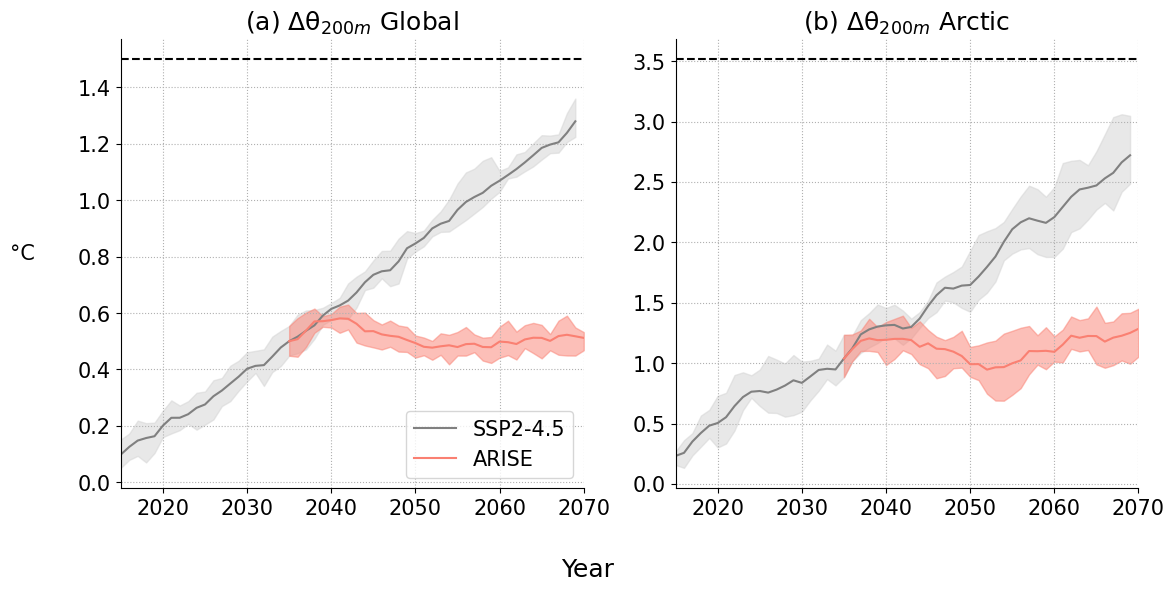

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

targets = [1.5, arctic_target - piCo_arctic]   # surface-air targets, unchanged from panels b/c
i = 0
for region in ['Global', 'Arctic']:
    ax = axs[i]
    ax.axhline(targets[i], color='black', ls='--')
    piCo = piCo_thetao_200m[region]

    ts_ssp = SSP245_thetao_ts_dict[region].thetao
    ax.plot(ts_ssp.mean('Ensemble_member').time.dt.year.values,
            ts_ssp.mean('Ensemble_member') - piCo,
            c=colours['ssp245'], label='SSP2-4.5' if i == 0 else None)
    ax.fill_between(ts_ssp.isel(Ensemble_member=0).time.dt.year.values,
                    ts_ssp.min('Ensemble_member').values - piCo,
                    ts_ssp.max('Ensemble_member').values - piCo,
                    color=colours['ssp245_light'], alpha=0.5)

    ts_arise = arise_thetao_ts_dict[region].thetao
    ax.plot(ts_arise.mean('Ensemble_member').time.dt.year.values,
            ts_arise.mean('Ensemble_member') - piCo,
            c='salmon', label='ARISE' if i == 0 else None)
    ax.fill_between(ts_arise.isel(Ensemble_member=0).time.dt.year.values,
                    ts_arise.min('Ensemble_member').values - piCo,
                    ts_arise.max('Ensemble_member').values - piCo,
                    color='salmon', alpha=0.5)
    i += 1

for ax in axs:
    ax.set_xlim(2015, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_xlabel('')

axs[0].set_title('(a) Δθ$_{200m}$ Global')
axs[1].set_title('(b) Δθ$_{200m}$ Arctic')
axs[0].set_ylabel('°C', rotation=0, labelpad=40)
axs[0].legend()
fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('figures/thetao200m_timeseries.jpg', dpi=350, bbox_inches='tight')

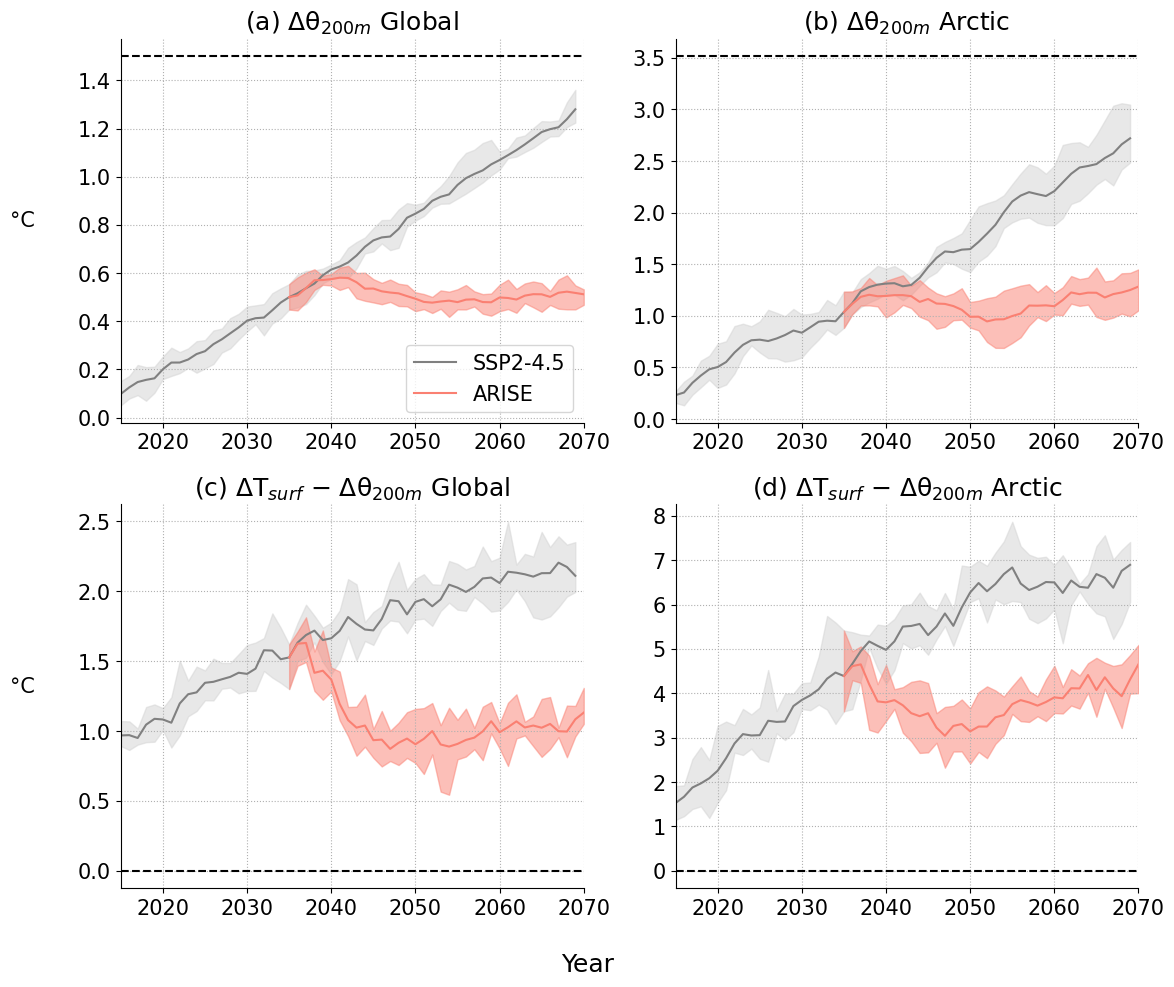

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

## --- top row: (a), (b) Δθ200m vs pre-industrial, as before ---
targets = [1.5, arctic_target - piCo_arctic]   # surface-air targets, unchanged from panels b/c
i = 0
for region in ['Global', 'Arctic']:
    ax = axs[0, i]
    ax.axhline(targets[i], color='black', ls='--')
    piCo = piCo_thetao_200m[region]

    ts_ssp = SSP245_thetao_ts_dict[region].thetao
    ax.plot(ts_ssp.mean('Ensemble_member').time.dt.year.values,
            ts_ssp.mean('Ensemble_member') - piCo,
            c=colours['ssp245'], label='SSP2-4.5' if i == 0 else None)
    ax.fill_between(ts_ssp.isel(Ensemble_member=0).time.dt.year.values,
                    ts_ssp.min('Ensemble_member').values - piCo,
                    ts_ssp.max('Ensemble_member').values - piCo,
                    color=colours['ssp245_light'], alpha=0.5)

    ts_arise = arise_thetao_ts_dict[region].thetao
    ax.plot(ts_arise.mean('Ensemble_member').time.dt.year.values,
            ts_arise.mean('Ensemble_member') - piCo,
            c='salmon', label='ARISE' if i == 0 else None)
    ax.fill_between(ts_arise.isel(Ensemble_member=0).time.dt.year.values,
                    ts_arise.min('Ensemble_member').values - piCo,
                    ts_arise.max('Ensemble_member').values - piCo,
                    color='salmon', alpha=0.5)
    i += 1

## --- bottom row: (c), (d) surface anomaly minus 200 m anomaly ---
piCo_surface = {'Global': piCo_global, 'Arctic': piCo_arctic}
i = 0
for region in ['Global', 'Arctic']:
    ax = axs[1, i]
    ax.axhline(0, color='black', ls='--')   # surface and subsurface anomalies equal

    # per-member: (tas - piCo_surface) - (theta200 - piCo_ocean); units cancel (K anomaly == °C anomaly)
    # xarray aligns on time (intersection), Ensemble_member aligns by position -- see ordering caveat
    diff_ssp = ((SSP245_timeseries_dict[region].tas - piCo_surface[region])
                - (SSP245_thetao_ts_dict[region].thetao - piCo_thetao_200m[region]))
    ax.plot(diff_ssp.mean('Ensemble_member').time.dt.year.values,
            diff_ssp.mean('Ensemble_member'),
            c=colours['ssp245'])
    ax.fill_between(diff_ssp.isel(Ensemble_member=0).time.dt.year.values,
                    diff_ssp.min('Ensemble_member').values,
                    diff_ssp.max('Ensemble_member').values,
                    color=colours['ssp245_light'], alpha=0.5)

    diff_arise = ((arise_tas_timeseries_dict[region].tas - piCo_surface[region])
                  - (arise_thetao_ts_dict[region].thetao - piCo_thetao_200m[region]))
    ax.plot(diff_arise.mean('Ensemble_member').time.dt.year.values,
            diff_arise.mean('Ensemble_member'),
            c='salmon')
    ax.fill_between(diff_arise.isel(Ensemble_member=0).time.dt.year.values,
                    diff_arise.min('Ensemble_member').values,
                    diff_arise.max('Ensemble_member').values,
                    color='salmon', alpha=0.5)
    i += 1

for ax in axs.flatten():
    ax.set_xlim(2015, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Δθ$_{200m}$ Global')
axs[0, 1].set_title('(b) Δθ$_{200m}$ Arctic')
axs[1, 0].set_title('(c) ΔT$_{surf}$ − Δθ$_{200m}$ Global')
axs[1, 1].set_title('(d) ΔT$_{surf}$ − Δθ$_{200m}$ Arctic')
axs[0, 0].set_ylabel('°C', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('°C', rotation=0, labelpad=40)
axs[0, 0].legend()
fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('figures/thetao200m_timeseriesv2.jpg', dpi=350, bbox_inches='tight')

In [32]:
## --- surface ocean temperature (tos) for the surface-vs-200m comparison ---

def open_tos(path_glob, time_slice=None):
    """Open Omon tos lazily (2-D field, no depth axis)."""
    ds = xr.open_mfdataset(path_glob, combine='by_coords', chunks={'time': 120})
    ds = ds[['tos']]
    if time_slice is not None:
        ds = ds.sel(time=slice(*time_slice))
    return ds

ssp245_tos_tmpl = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/{m}/Omon/tos/gn/latest/*.nc'

ds_list = []
for m in ens_mems_arise_UK:
    print(m)
    ds_list.append(open_tos(ssp245_tos_tmpl.format(m=m), time_slice=('2015', '2069')))
DS_ssp245_tos = xr.concat(ds_list, dim='Ensemble_member')
print('Units:', DS_ssp245_tos.tos.attrs.get('units'))

SSP245_tos_ts_dict = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(DS_ssp245_tos, region)
    ts = weighted_annual_resample(ts, 'tos')
    ts.load()
    SSP245_tos_ts_dict[region] = ts

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2
Units: degC


In [33]:
paths_tos_ARISE = sorted(glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Omon/tos/gn/*/'))

ds_list = []
for p in paths_tos_ARISE:
    run_id = p.split('/')[-6]
    print(run_id)
    ds_list.append(open_tos(p + '/*.nc'))
ds_arise_tos = xr.concat(ds_list, dim='Ensemble_member')

arise_tos_ts_dict = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(ds_arise_tos, region)
    ts = weighted_annual_resample(ts, 'tos')
    ts.load()
    arise_tos_ts_dict[region] = ts

r1i1p1f2
r2i1p1f2
r3i1p1f2
r4i1p1f2
r8i1p1f2


In [34]:
piCo_tos_paths = sorted(glob.glob('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/tos/gn/latest/*.nc'))
print(len(piCo_tos_paths), 'files')

ds_piCo_tos = open_tos(piCo_tos_paths[0])   # same ~40 yr window as the thetao baseline

piCo_tos = {}
for region in ['Global', 'Arctic']:
    ts = ocean_spatial_mean(ds_piCo_tos, region)
    piCo_tos[region] = float(ts.tos.mean('time').load())
print(piCo_tos)

20 files
{'Global': 17.710512161254883, 'Arctic': -0.5560545921325684}


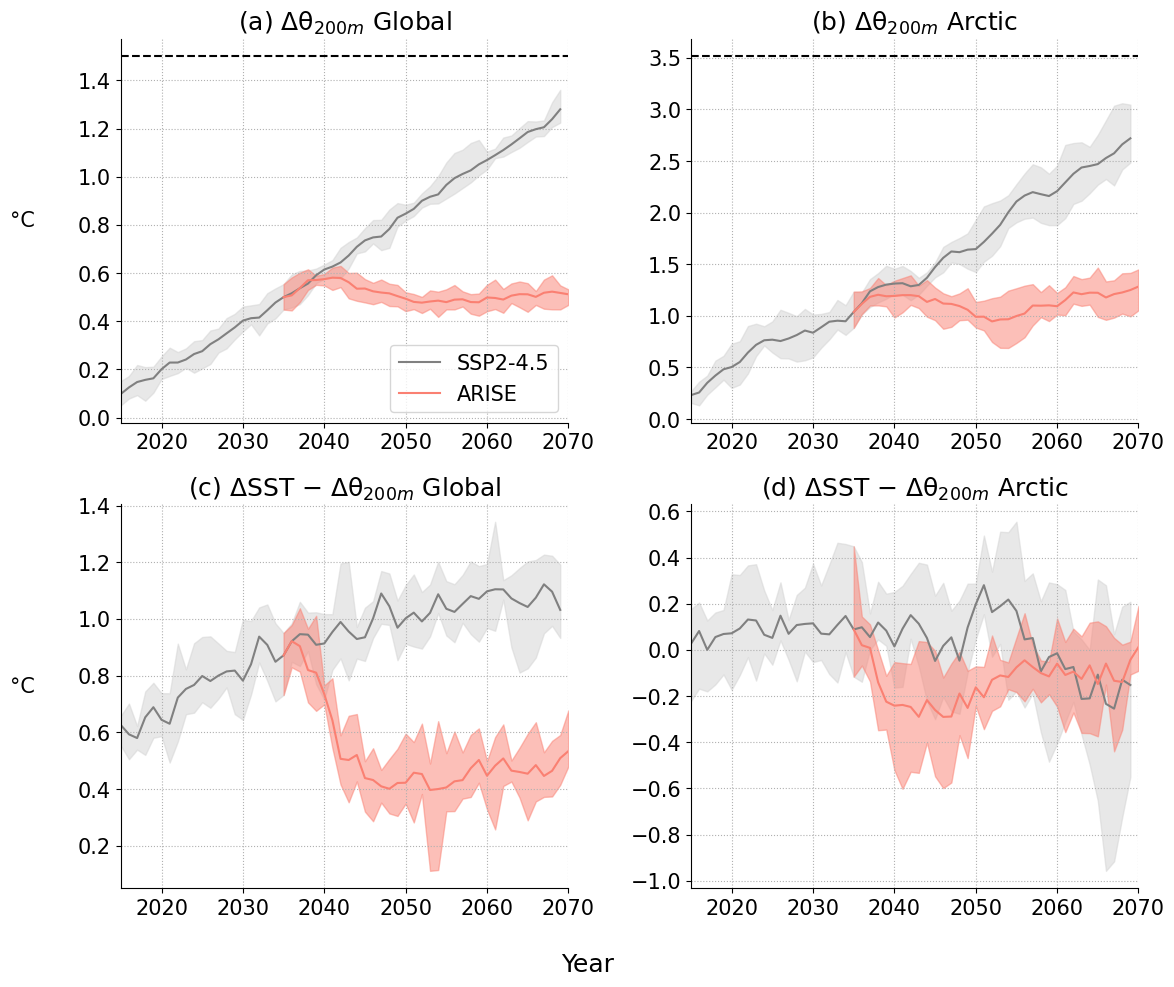

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

## --- top row: (a), (b) Δθ200m vs pre-industrial ---
targets = [1.5, arctic_target - piCo_arctic]   # surface-air targets, unchanged from panels b/c
i = 0
for region in ['Global', 'Arctic']:
    ax = axs[0, i]
    ax.axhline(targets[i], color='black', ls='--')
    piCo = piCo_thetao_200m[region]

    ts_ssp = SSP245_thetao_ts_dict[region].thetao
    ax.plot(ts_ssp.mean('Ensemble_member').time.dt.year.values,
            ts_ssp.mean('Ensemble_member') - piCo,
            c=colours['ssp245'], label='SSP2-4.5' if i == 0 else None)
    ax.fill_between(ts_ssp.isel(Ensemble_member=0).time.dt.year.values,
                    ts_ssp.min('Ensemble_member').values - piCo,
                    ts_ssp.max('Ensemble_member').values - piCo,
                    color=colours['ssp245_light'], alpha=0.5)

    ts_arise = arise_thetao_ts_dict[region].thetao
    ax.plot(ts_arise.mean('Ensemble_member').time.dt.year.values,
            ts_arise.mean('Ensemble_member') - piCo,
            c='salmon', label='ARISE' if i == 0 else None)
    ax.fill_between(ts_arise.isel(Ensemble_member=0).time.dt.year.values,
                    ts_arise.min('Ensemble_member').values - piCo,
                    ts_arise.max('Ensemble_member').values - piCo,
                    color='salmon', alpha=0.5)
    i += 1

## --- bottom row: (c), (d) SST anomaly minus 200 m anomaly (both ocean-only, same mask) ---
i = 0
for region in ['Global', 'Arctic']:
    ax = axs[1, i]
    #ax.axhline(0, color='black')   # surface and subsurface anomalies equal

    # per-member: (tos - piCo_tos) - (theta200 - piCo_theta200)
    # time aligns on intersection; Ensemble_member aligns by position (globs sorted)
    diff_ssp = ((SSP245_tos_ts_dict[region].tos - piCo_tos[region])
                - (SSP245_thetao_ts_dict[region].thetao - piCo_thetao_200m[region]))
    ax.plot(diff_ssp.mean('Ensemble_member').time.dt.year.values,
            diff_ssp.mean('Ensemble_member'),
            c=colours['ssp245'])
    ax.fill_between(diff_ssp.isel(Ensemble_member=0).time.dt.year.values,
                    diff_ssp.min('Ensemble_member').values,
                    diff_ssp.max('Ensemble_member').values,
                    color=colours['ssp245_light'], alpha=0.5)

    diff_arise = ((arise_tos_ts_dict[region].tos - piCo_tos[region])
                  - (arise_thetao_ts_dict[region].thetao - piCo_thetao_200m[region]))
    ax.plot(diff_arise.mean('Ensemble_member').time.dt.year.values,
            diff_arise.mean('Ensemble_member'),
            c='salmon')
    ax.fill_between(diff_arise.isel(Ensemble_member=0).time.dt.year.values,
                    diff_arise.min('Ensemble_member').values,
                    diff_arise.max('Ensemble_member').values,
                    color='salmon', alpha=0.5)
    i += 1

for ax in axs.flatten():
    ax.set_xlim(2015, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Δθ$_{200m}$ Global')
axs[0, 1].set_title('(b) Δθ$_{200m}$ Arctic')
axs[1, 0].set_title('(c) ΔSST − Δθ$_{200m}$ Global')
axs[1, 1].set_title('(d) ΔSST − Δθ$_{200m}$ Arctic')
axs[0, 0].set_ylabel('°C', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('°C', rotation=0, labelpad=40)
axs[0, 0].legend()
fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('figures/thetao200m_timeseriesv3.jpg', dpi=350, bbox_inches='tight')